# Telecom Customer Churn Prediction

https://www.kaggle.com/datasets/palashfendarkar/wa-fnusec-telcocustomerchurn


### Executive Summary

The objective of this analysis was to build a predictive model to identify customers who are likely to churn so the company can take proactive retention actions. Exploratory data analysis (EDA) was conducted to understand the dataset and revealed a significant class imbalance, with far fewer churners than non-churners. Because of this imbalance, recall was used as the primary evaluation metric to ensure the models focus on correctly identifying customers who actually churn.

Several machine learning models, including KNN, Random Forest, and Decision Tree, were developed and evaluated. Hyperparameter tuning was performed using a tournament-style approach to determine the optimal configuration for each model.

Among the models tested, the Decision Tree achieved the highest recall on the test set, indicating it is the most effective at identifying customers at risk of churning while maintaining good generalization. As a result, the Decision Tree model is recommended to support targeted retention strategies and reduce customer churn.

### Data Dictionary

| Variable | Description |
| --- | --- |
|CustomerID| Unique customer ID|
|Gender|Customer's gender|
|SeniorCitizen|Whether the customer is a senior citizen or not (1, 0)|
|Partner|Whether the customer has a partner or not (Yes, No)|
|Dependents|Whether the customer has dependents or not (Yes, No)|
|Tenure|Number of months the customer has stayed with the company|
|PhoneService|Whether the customer has a phone service or not (Yes, No)|
|MultipleLines|Whether the customer has multiple lines or not (Yes, No, No phone service)|
|InternetService|Customer’s internet service provider (DSL, Fiber optic, No)|
|OnlineSecurity|Whether the customer has online security or not (Yes, No, No internet service)|
|OnlineBackup|Whether the customer has online backup or not (Yes, No, No internet service)|
|DeviceProtection|Whether the customer has device protection or not (Yes, No, No internet service)|
|TechSupport|Whether the customer has tech support or not (Yes, No, No internet service)|
|StreamingTV|Whether the customer has streaming TV or not (Yes, No, No internet service)|
|StreamingMovies|Whether the customer has streaming movies or not (Yes, No, No internet service)|
|Contract|The contract term of the customer (Month-to-month, One year, Two year)|
|PaperlessBilling|Whether the customer has paperless billing or not (Yes, No)|
|PaymentMethod|The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))|
|MonthlyCharges|The amount charged to the customer monthly|
|TotalCharges|The total amount charged to the customer|
|Churn|Whether the customer churned or not (Yes or No)|

In [5]:
#Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier       # Decision Tree
from sklearn.metrics import recall_score              # recall_score
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [6]:
#Loading the dataset
churn_df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
churn_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Preprocessing Part 1

In [8]:
#Checking the shape of the dataset
churn_df.shape

(7043, 21)

In [9]:
#drop the customer because it has no analytical value
churn_df.drop(columns='customerID', inplace=True)

In [10]:
#Checking for duplicate values
churn_df.duplicated().sum()

np.int64(22)

In [11]:
#Removing the duplicate values
churn_df.drop_duplicates(inplace=True)

In [12]:
#inspect the data types
churn_df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [13]:
#Type casting column Total Charges
churn_df['TotalCharges'] = pd.to_numeric(churn_df['TotalCharges'], errors='coerce')

In [14]:
#Checking for null values
churn_df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [15]:
#Droping the null values
churn_df.dropna(inplace=True)

<h4>Descriptive Statistics </h4>

In [17]:
churn_df.describe(include='number').round(decimals = 2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7010.00,7010.00,7010.00,7010.00
mean,0.16,32.52,64.89,2290.35
std,0.37,24.52,30.06,2266.82
min,0.00,1.00,18.25,18.80
25%,0.00,9.00,35.75,408.31
50%,0.00,29.00,70.40,1403.88
75%,0.00,56.00,89.90,3807.84
max,1.00,72.00,118.75,8684.80


## Exploratory Data Analysis

In the exploratory data analysis phase, the dataset will be visualized to gain a deeper understanding of its structure and characteristics, as well as to identify any trends or patterns that may influence customer churn. The analysis will begin by examining the distribution of the variables to understand their spread, central tendencies, and potential outliers.

Following this, the relationships between the independent variables and the target variable (customer churn) will be explored using appropriate visualizations. This will help identify which features may have stronger associations with churn and provide insights that can guide feature selection and model development.

### Customer Demographics

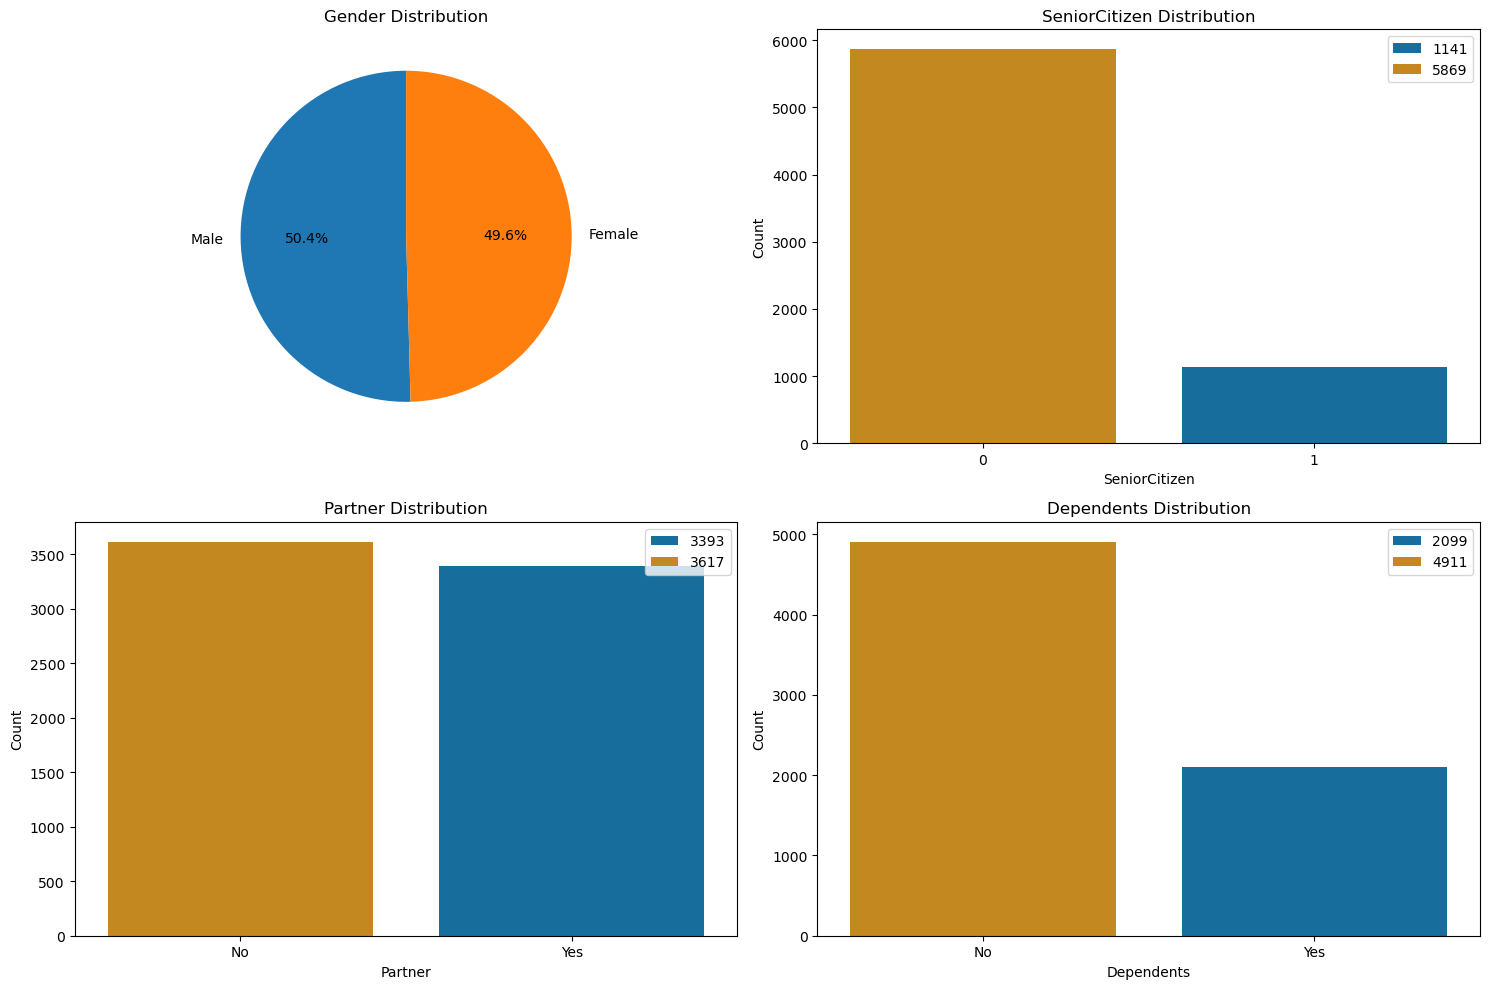

In [21]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# -----------------------------
# Gender Distribution (Pie)
# -----------------------------
gender_counts = churn_df['gender'].value_counts()

ax[0,0].pie( gender_counts,
             labels     = gender_counts.index,
             autopct    = '%1.1f%%',
             startangle = 90
            )
ax[0,0].set_title('Gender Distribution')

# -----------------------------
# Bar Plot Variables
# -----------------------------
features = ['SeniorCitizen', 'Partner', 'Dependents']
positions = [(0,1), (1,0), (1,1)]

for feature, pos in zip(features, positions):
    
    counts = churn_df[feature].value_counts().sort_index()
    
    sns.barplot(x  = counts.index,
                y  = counts.values,
                ax = ax[pos],
                hue= counts.values,
               palette = 'colorblind')
    
    ax[pos].set_title(f'{feature} Distribution')
    ax[pos].set_xlabel(feature)
    ax[pos].set_ylabel('Count')


plt.tight_layout()
plt.savefig("images/customer_demographics_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

The demographic analysis shows that the customer base is almost evenly split by gender, with males representing about 50.5% and females 49.5%, indicating that the service appeals equally to both genders. The majority of customers are not senior citizens, suggesting that the customer base is largely composed of working-age adults as compared to retirees. In terms of relationship status, the distribution between customers with partners and those without partners is fairly balanced, although slightly more customers do not have partners. Additionally, most customers do not have dependents, which may indicate that a large portion of the customer base consists of individuals or couples without children. Overall, the demographics suggest that the service primarily attracts non-senior, independent adults with relatively balanced gender representation.

### Tenure and Contract

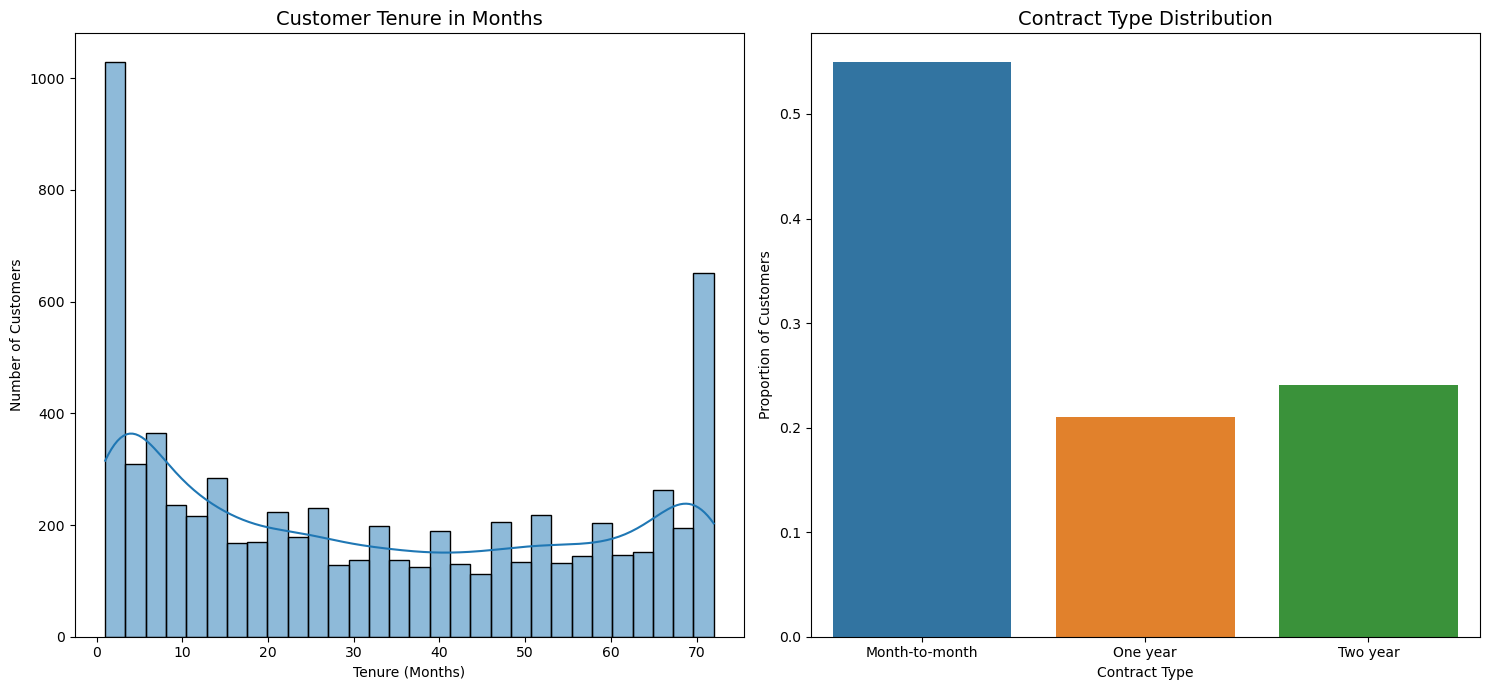

In [27]:
# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

# Histogram for customer tenure
sns.histplot(data  = churn_df,
             x     = 'tenure',
             bins  = 30,
             kde   = True,
             ax    = ax[0])

ax[0].set_title('Customer Tenure in Months', fontsize=14)
ax[0].set_xlabel('Tenure (Months)')
ax[0].set_ylabel('Number of Customers')

# Countplot for contract type
sns.countplot(data = churn_df,
              x    = 'Contract',
              hue  = 'Contract',
              stat = 'proportion',
              ax   = ax[1])
ax[1].set_title('Contract Type Distribution', fontsize=14)
ax[1].set_xlabel('Contract Type')
ax[1].set_ylabel('Proportion of Customers')

# Improve spacing
plt.tight_layout()
plt.savefig("images/tenure_contract_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

### Services

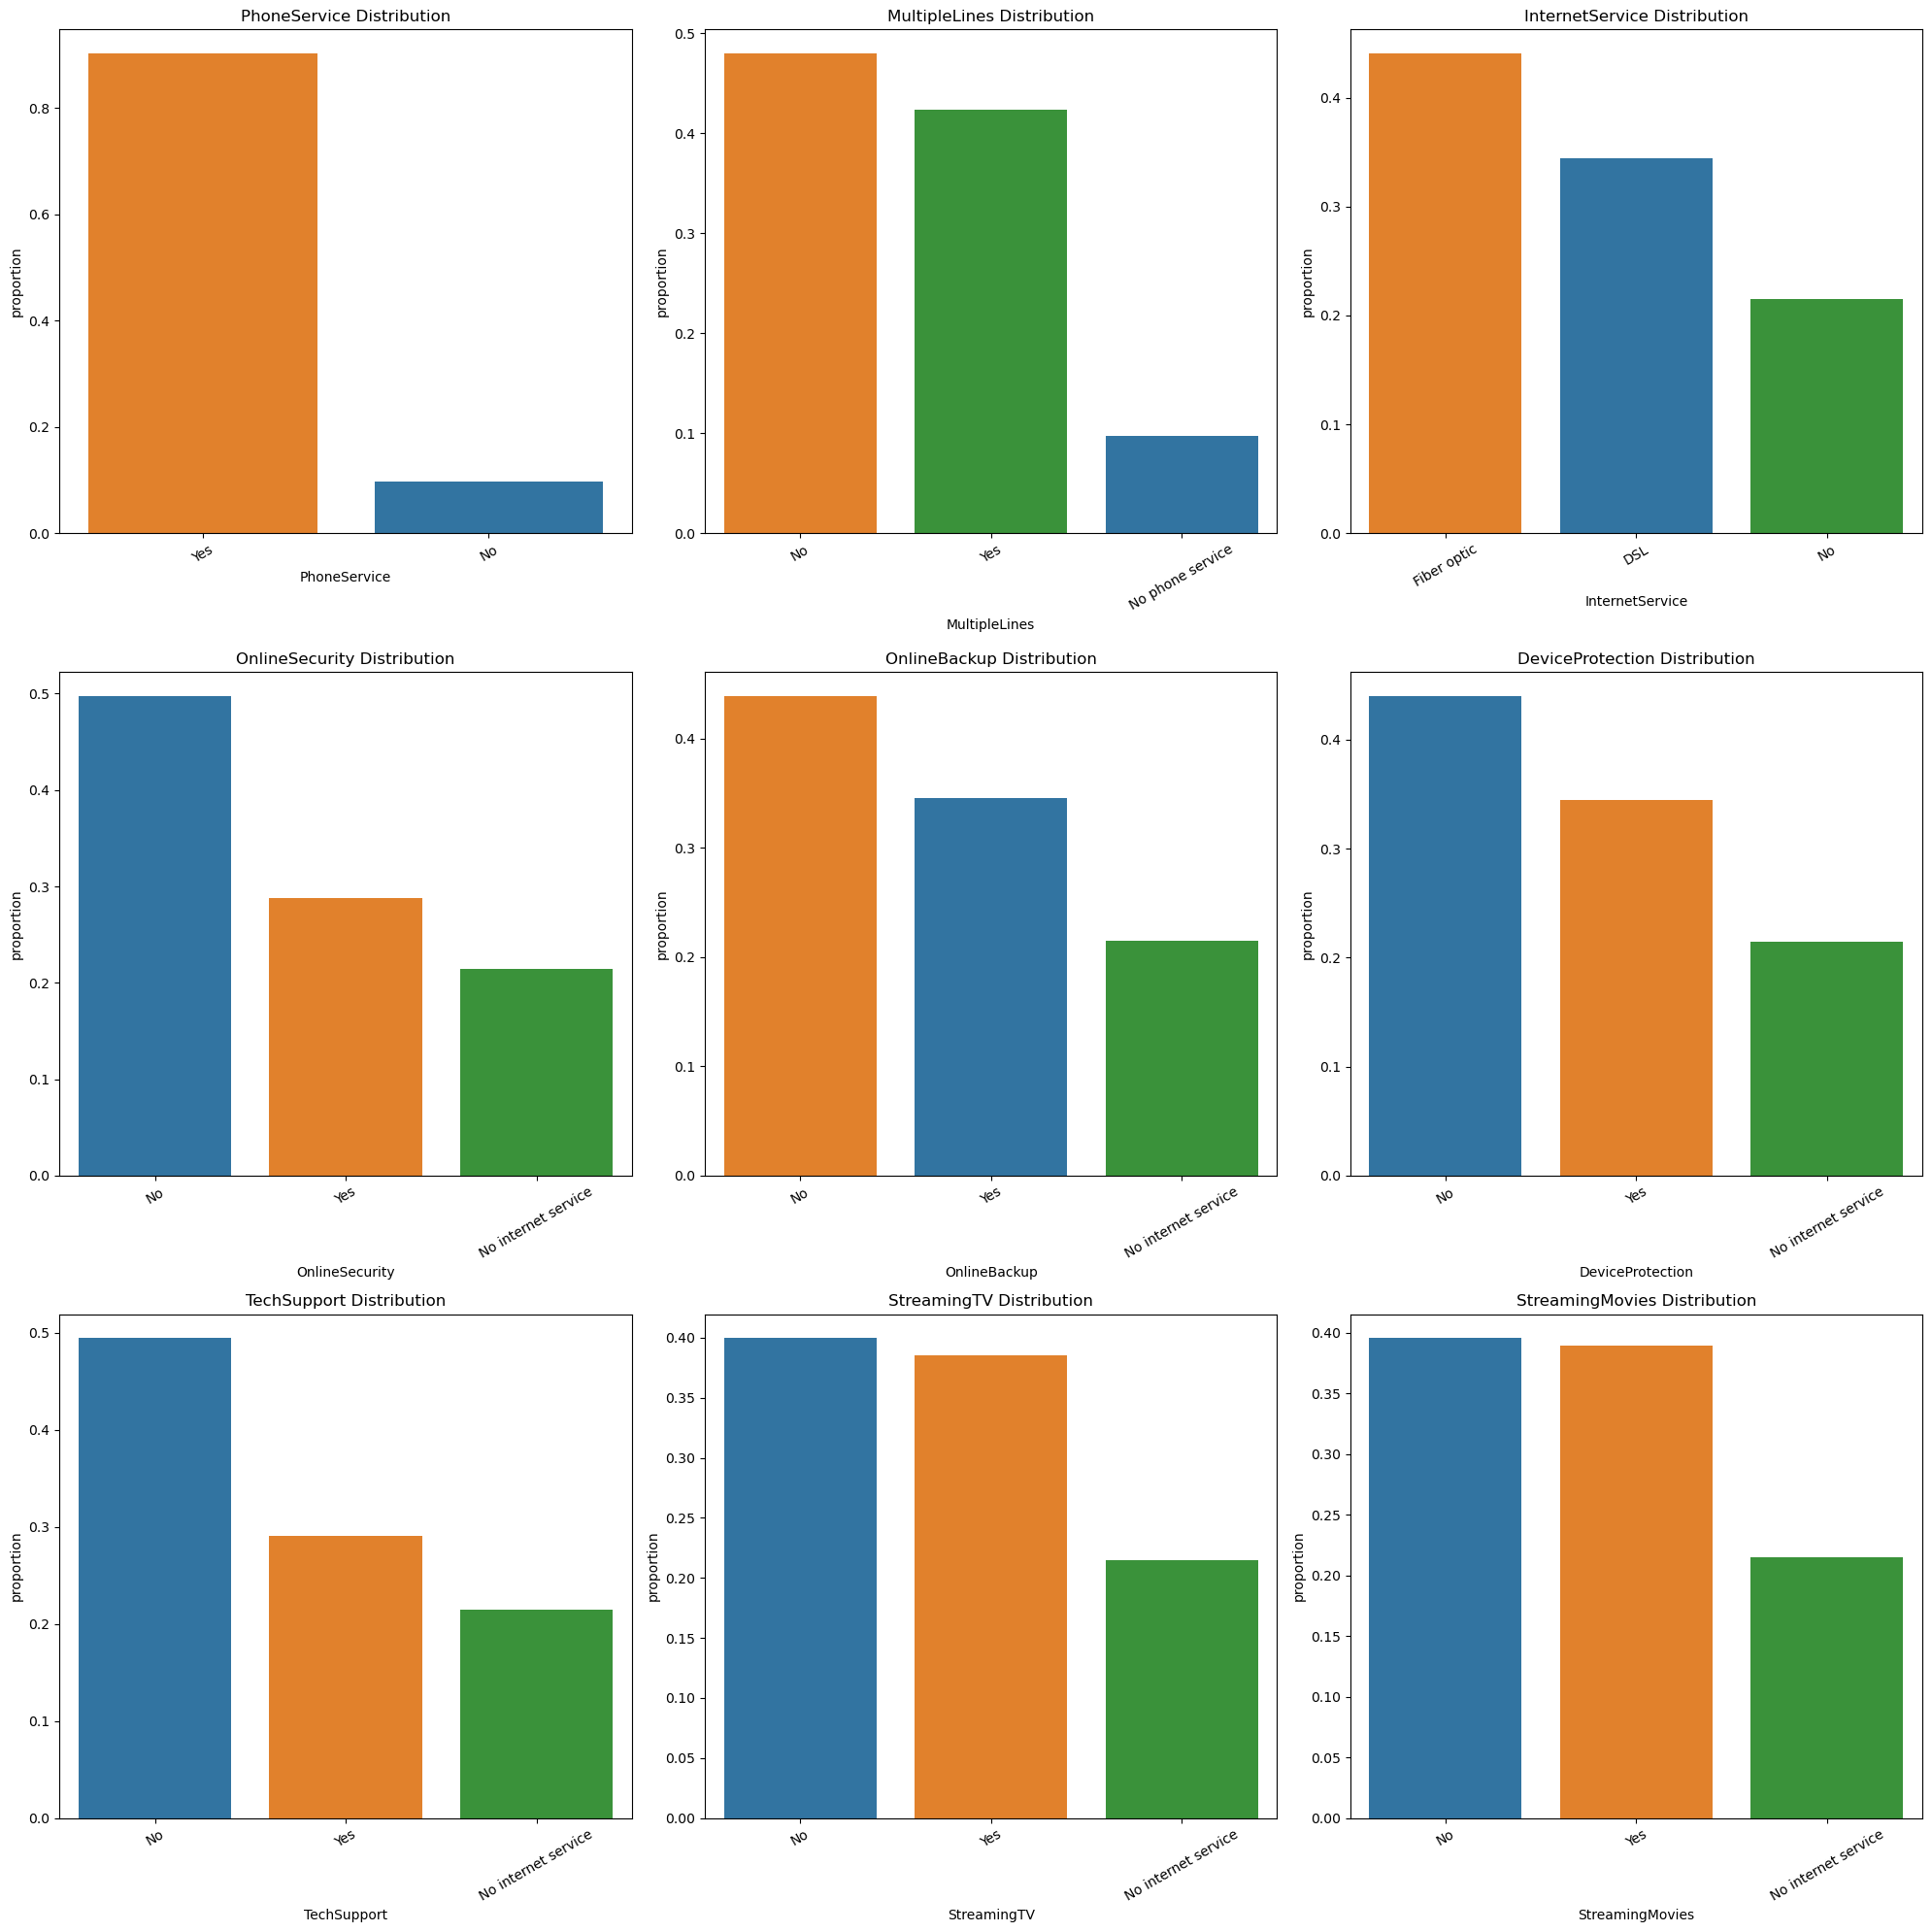

In [24]:
# Features to visualize
features = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Create subplot grid
fig, ax = plt.subplots(3, 3, figsize=(20, 20))

# Flatten axes for easy iteration
ax = ax.flatten()

# Plot countplots
for i, feature in enumerate(features):
    
    sns.countplot(x     = churn_df[feature],
                  ax    = ax[i],
                  order = churn_df[feature].value_counts().index,
                  stat  = 'proportion',
                  hue = churn_df[feature]
                 )
    
    ax[i].set_title(f'{feature} Distribution')
    ax[i].set_xlabel(feature)
    ax[i].set_ylabel('proportion')
    ax[i].tick_params(axis='x', rotation=30)

plt.tight_layout()

plt.savefig("images/service_features_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

The distribution of service features shows that the customer base is heavily anchored in telephony, with roughly 90% adoption, but there is a notable protection gap in digital services such as Online Security, Tech Support, and Device Protection. While Fiber Optic is the preferred internet medium, high engagement in Streaming TV and Movies indicates that customers primarily view the service as an entertainment utility rather than a technical or security hub. This imbalance exposes the provider to strategic vulnerability, as customers are not deeply integrated into “sticky” services, keeping switching costs low and making them more likely to churn if competitors offer superior entertainment packages.

To build long-term loyalty, the provider should focus on transitioning “entertainment-only” users into “secure-suite” users by promoting adoption of Online Backup, Security, and Device Protection. By integrating customers into a broader ecosystem of services, the company can increase reliance on its technical and data offerings, raise switching barriers, and reduce churn risk, effectively converting short-term entertainment users into long-term, loyal customers.


The tenure distribution highlights a critical **early-stage churn problem**. The very large spike in the first 0–2 months shows that a significant number of customers leave almost immediately after joining, creating what can be described as a **“leaky bucket” effect**, that is the company successfully acquires customers but struggles to retain them in the initial phase. However, the relatively flat distribution between 5 and 65 months suggests that once customers pass this early “danger zone,” their likelihood of leaving stabilizes significantly, indicating that they have integrated the service into their daily lives. The smaller spike around month 70 likely represents long-term loyal customers who have remained with the provider since the early stages of service adoption or data collection.

When combined with the contract type distribution, a clear **“trial vs. commitment” dynamic** emerges. The high number of month-to-month contracts appears to feed directly into the early tenure spike, creating an environment where new customers churn quickly. Since the middle tenure range remains stable, the key retention opportunity lies in the **first 90 days** rather than later in the customer lifecycle. Encouraging early adoption of value-adding services such as Tech Support, Online Security, or other integrated features can help “anchor” new customers, pushing them beyond the initial churn window and into the stable long-term segment, ultimately increasing overall customer lifetime value. 


### Billing and Charges

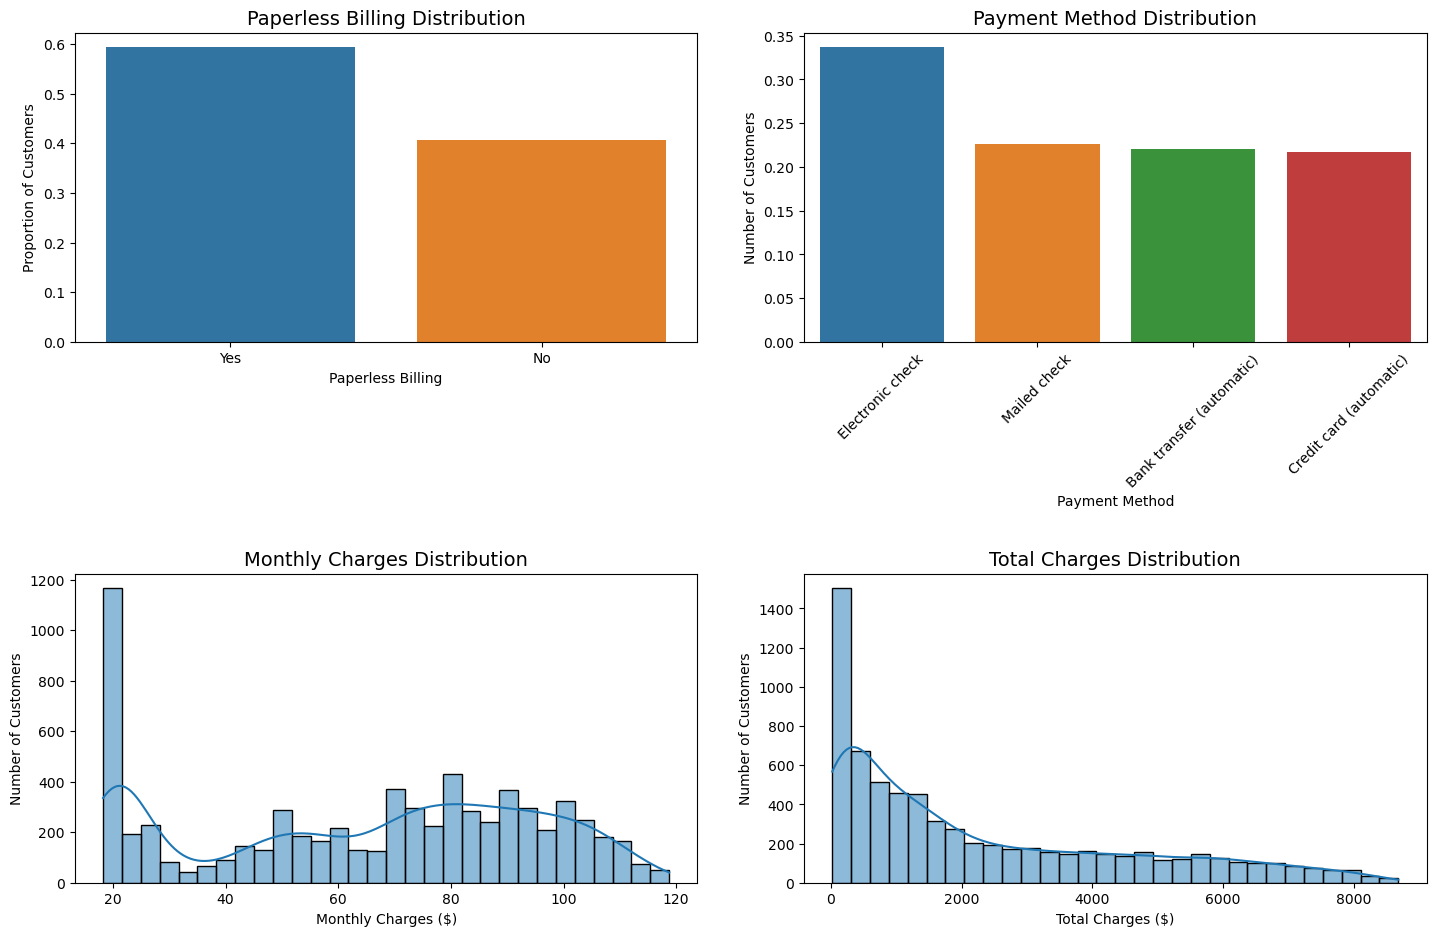

In [30]:
# Create 2x2 subplots
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Paperless Billing Countplot
sns.countplot(data = churn_df,
              x    = 'PaperlessBilling',
              hue  = 'PaperlessBilling', 
              stat = 'proportion',
              ax   = ax[0,0])

ax[0,0].set_title('Paperless Billing Distribution', fontsize=14)
ax[0,0].set_xlabel('Paperless Billing')
ax[0,0].set_ylabel('Proportion of Customers')

# Payment Method Countplot
sns.countplot(data = churn_df,
              x    = 'PaymentMethod',
              hue  = 'PaymentMethod',
               stat = 'proportion',
              ax   = ax[0,1])
ax[0,1].set_title('Payment Method Distribution', fontsize = 14)
ax[0,1].set_xlabel('Payment Method')
ax[0,1].set_ylabel('Number of Customers')
ax[0,1].tick_params(axis = 'x', rotation = 45)

# Monthly Charges Histogram
sns.histplot(data = churn_df,
             x    = 'MonthlyCharges',
             bins = 30,
             kde  = True,
             ax   = ax[1,0])

ax[1,0].set_title('Monthly Charges Distribution', fontsize=14)
ax[1,0].set_xlabel('Monthly Charges ($)')
ax[1,0].set_ylabel('Number of Customers')

# Total Charges Histogram
sns.histplot(data = churn_df,
             x    = 'TotalCharges',
             bins = 30,
             kde  = True,
             ax   = ax[1,1])

ax[1,1].set_title('Total Charges Distribution', fontsize=14)
ax[1,1].set_xlabel('Total Charges ($)')
ax[1,1].set_ylabel('Number of Customers')

# Adjust layout to avoid overlap
plt.tight_layout(pad=3.0)
plt.savefig("images/billing_and_charges_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

The financial and billing data highlights a clear divide between low-cost, high-churn customers and premium, high-value users. The large spike at the low end of Monthly Charges indicates a substantial segment on basic plans, likely limited to Phone Service, which is reflected in the high volume of low Total Charges. Many of these customers pay via Paperless Billing and Electronic Checks convenient options that require minimal engagement making them more prone to churn. In contrast, the broader plateau of customers points to a stable middle to upper tier segment, likely utilizing Fiber Optic internet and Streaming services, indicating deeper integration and higher retention.

Strategically, the concentration of customers with Total Charges under $500 aligns with the early tenure spike observed previously. This confirms that a large portion of Electronic Check and Month-to-Month users are essentially revolving door customers: they sign up for inexpensive plans, pay digitally for a short period, and leave before reaching significant lifetime value. Addressing this segment requires engagement strategies early in the customer lifecycle to move them from short-term, low-value users into longer-term, more loyal customers.

### Churn Count

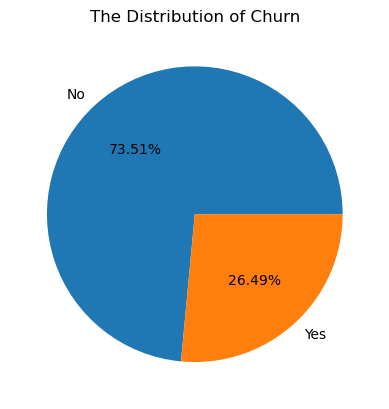

In [33]:
plt.pie(x = churn_df['Churn'].value_counts(), labels = churn_df['Churn'].unique(), autopct = '%1.2f%%')
plt.title('The Distribution of Churn')
plt.savefig("images/Customer Churn Distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

A 26.49% churn rate shows that while most customers stay, losing over a quarter is a warning sign in the competitive telecom market. The company retains its loyal long-term users well but struggles with month-to-month customers, who drive the early-tenure spike. Gaps in services like security and technical integration make it hard to convert these trial users into long-term customers, causing a portion of acquisition investment to be lost.

Strategically, the customer base splits into a stable, high-value minority and a volatile, low-value majority on short-term, low-cost plans. The churn rate highlights that early-stage engagement is critical: focusing on integrated services and security features can help move new users into the stable tenure range, improving retention and lifetime value.

### Customer Demogrpahics and Churn

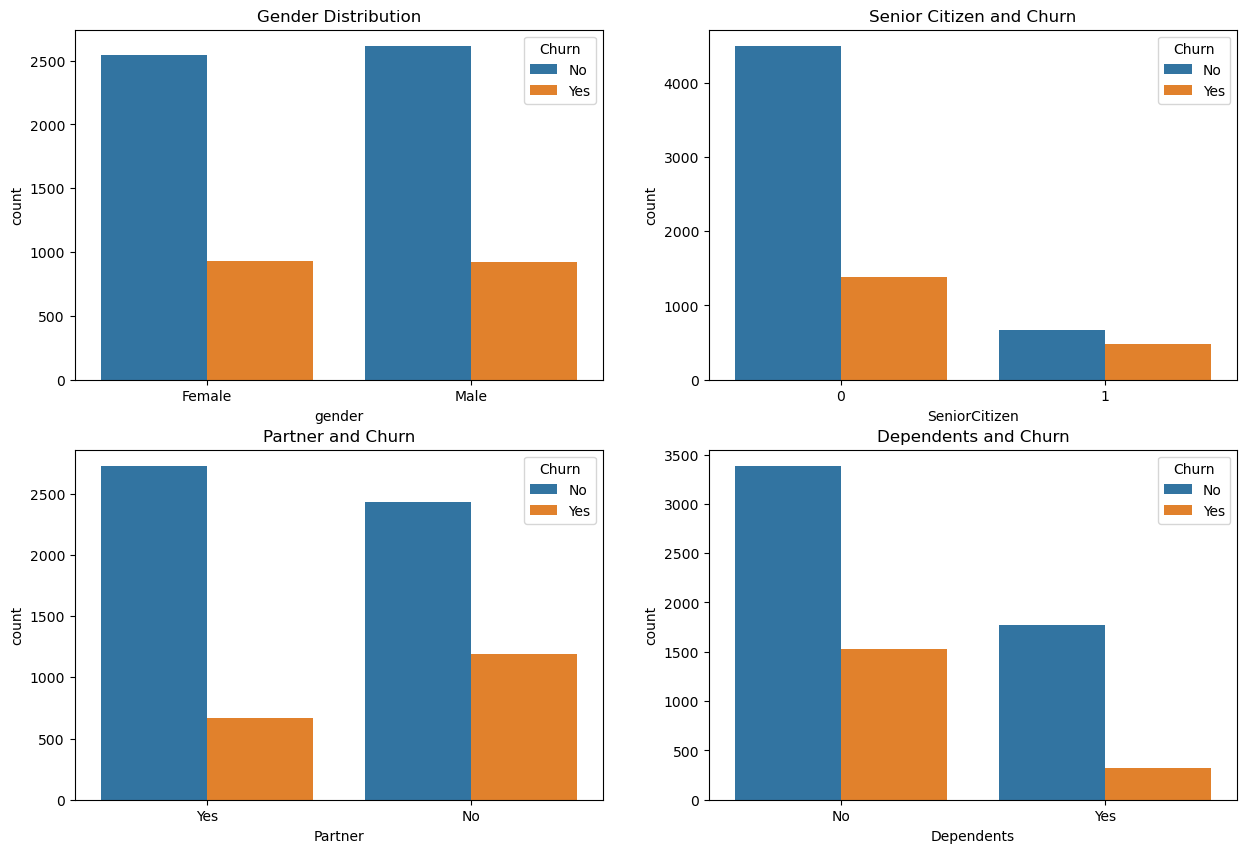

In [36]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

#Gender Distribution
sns.countplot(x    = 'gender',
              data = churn_df,
              hue  = 'Churn',
              ax   = ax[0,0])
ax[0,0].set_title('Gender Distribution')

#Senior Citizen Distribution
sns.countplot(x   = churn_df['SeniorCitizen'],
              ax  = ax[0,1],
              hue = churn_df['Churn']
             ).set_title('Senior Citizen and Churn')

#Partner Distribution
sns.countplot( x  = churn_df['Partner'],
              ax  = ax[1,0],
              hue = churn_df['Churn']
             ).set_title('Partner and Churn')

#Dependents Distribution
sns.countplot(x   = churn_df['Dependents'],
              ax  = ax[1,1],
              hue = churn_df['Churn']).set_title('Dependents and Churn')

plt.savefig("images/Relationship between Customer Demographics and Churn.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

The graphs provide insights into the relationship between customer demographics and churn. Churn counts are almost similar for both male and female customers, indicating that gender does not have a significant impact on churn. In contrast, senior citizens exhibit lower churn compared to non-senior customers, possibly due to a preference for stability and a reluctance to navigate the process of switching telecom providers.

Additionally, customers without partners show higher churn rates than those with partners, and similarly, customers without dependents are more likely to churn than those with dependents. Overall, the data suggests that single customers without partners or dependents are more prone to churn, while senior citizens demonstrate stronger retention.

### Services and Churn

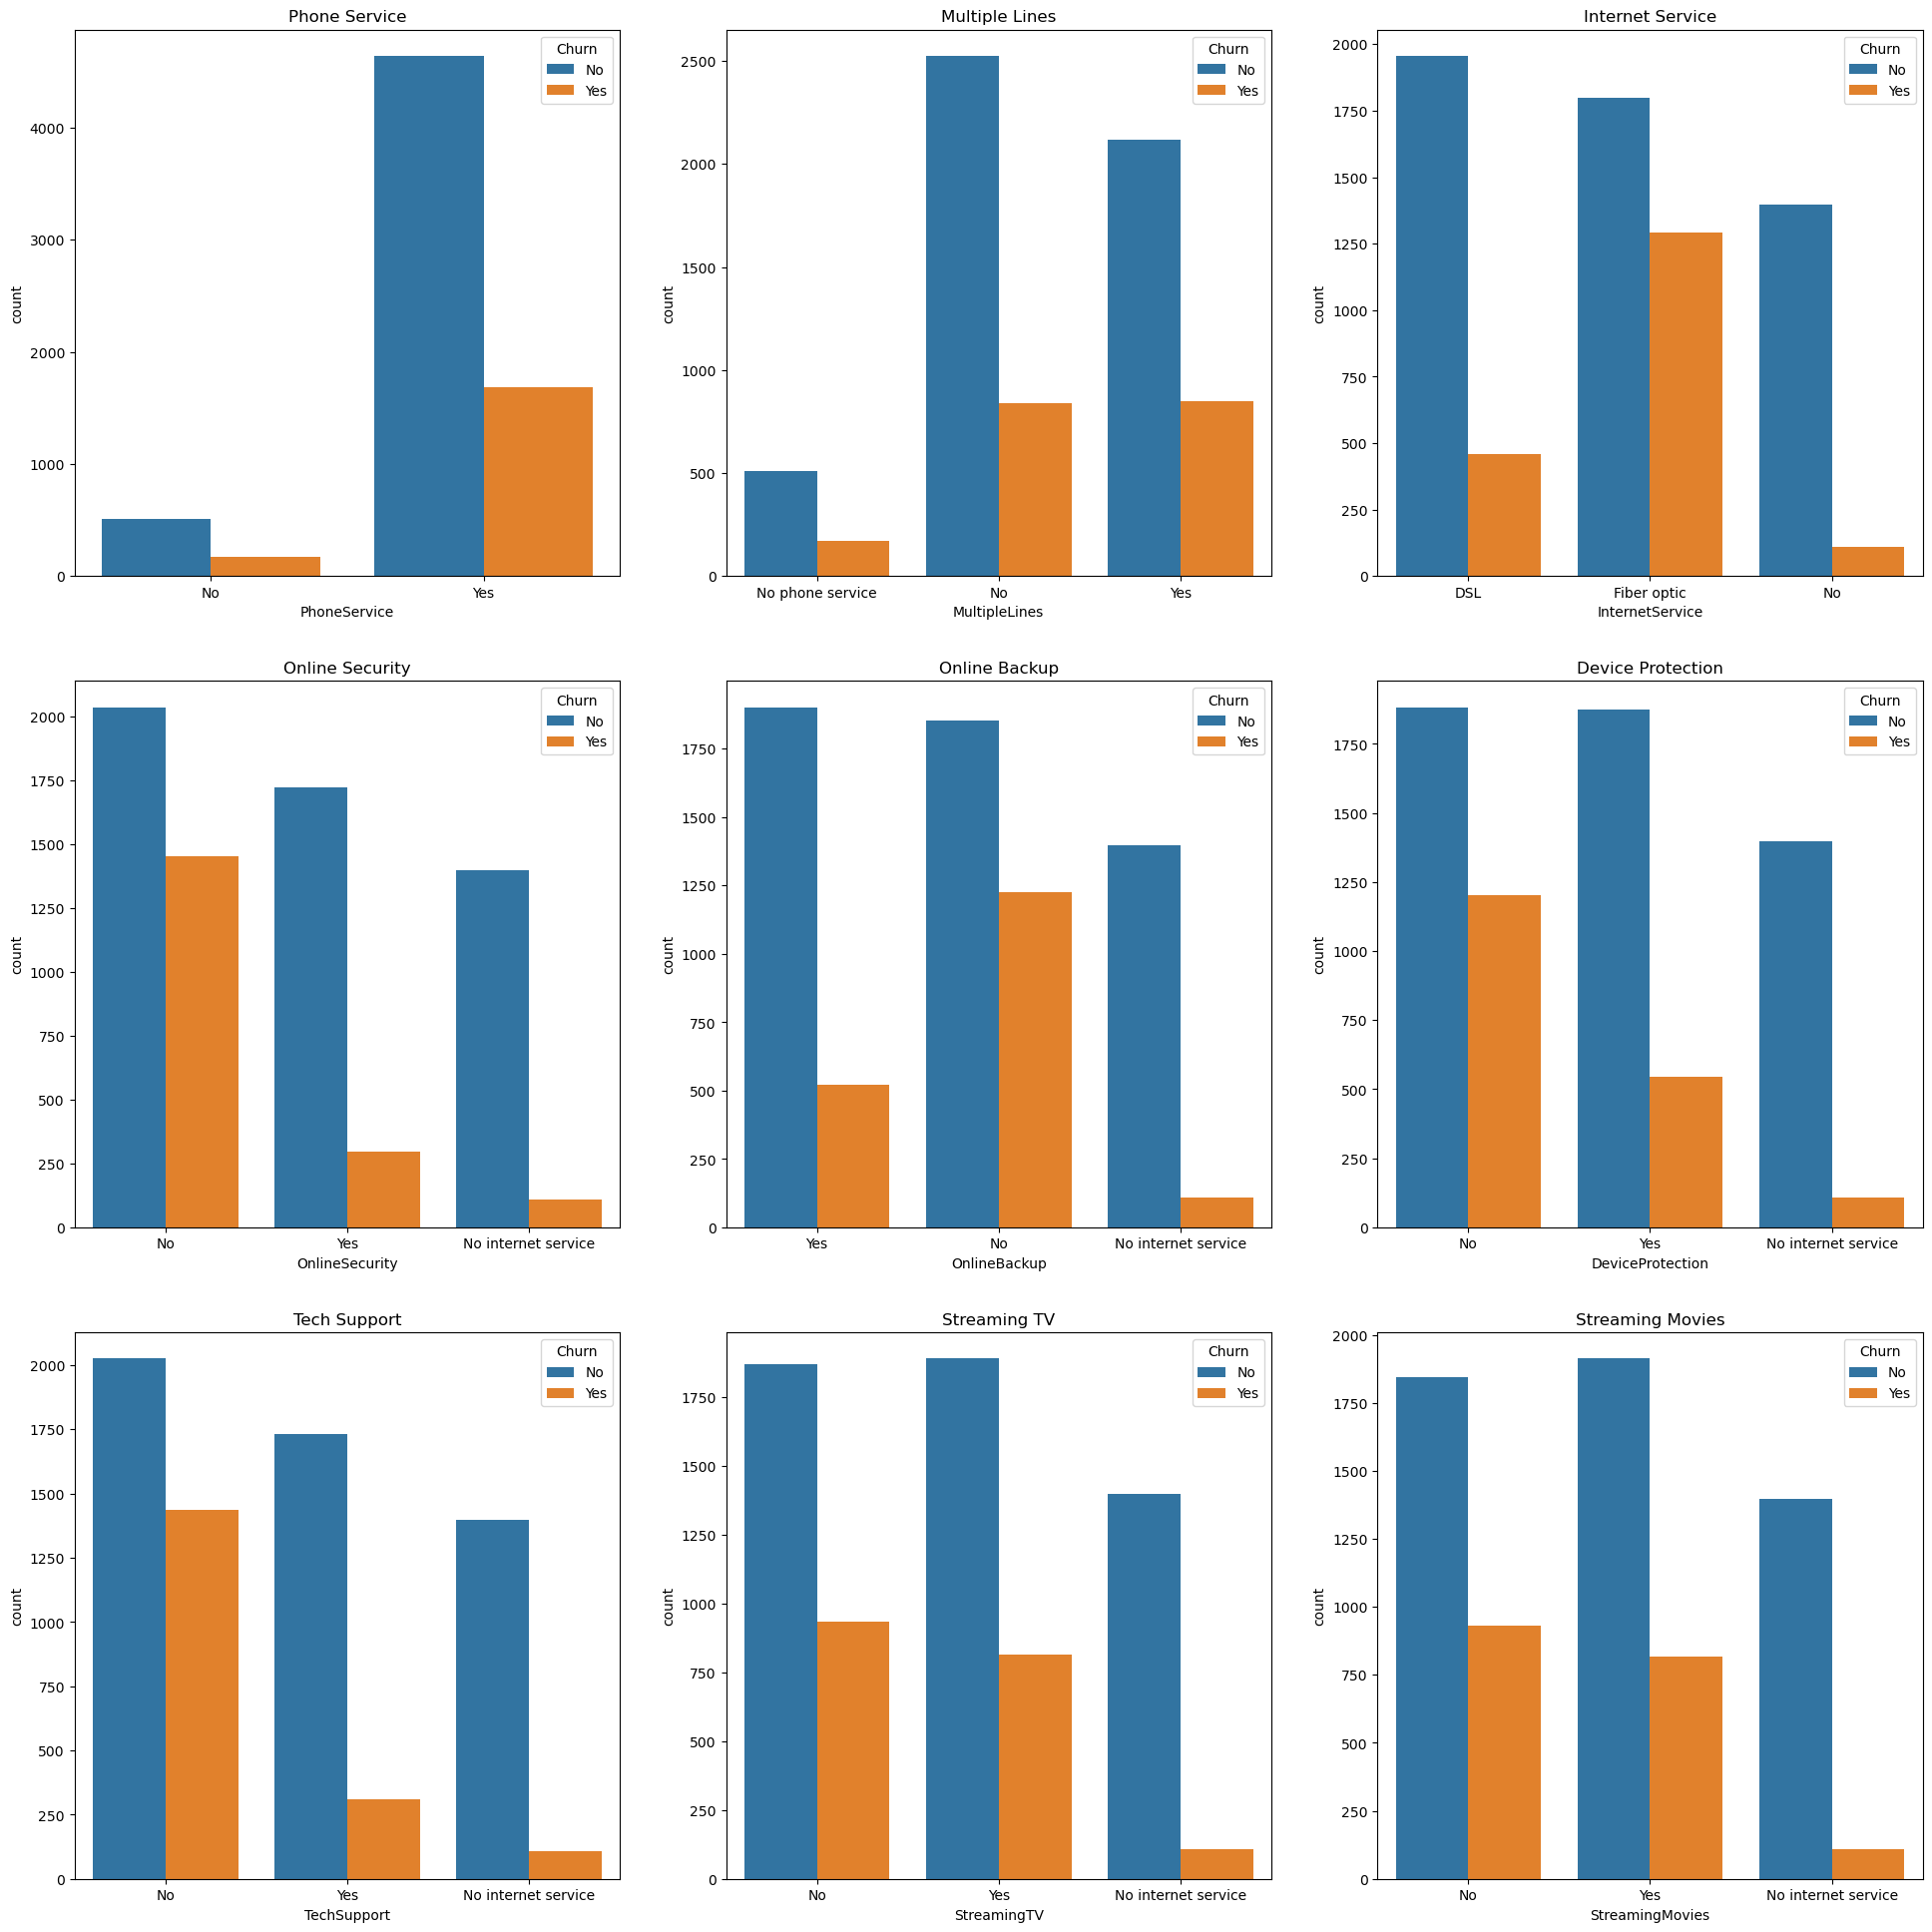

In [39]:
fig, ax = plt.subplots(3, 3, figsize=(20, 20))
#phone service
sns.countplot(x   = churn_df['PhoneService'],
              ax  = ax[0,0],
              hue = churn_df['Churn']).set_title('Phone Service')
ax[0,0].set_title('Phone Service')

#Multiple Lines
sns.countplot(x   = churn_df['MultipleLines'],
              ax  = ax[0,1], 
              hue = churn_df['Churn']).set_title('Multiple Lines')
ax[0,1].set_title('Multiple Lines')

#Internet Service
sns.countplot(x   = churn_df['InternetService'],
              ax  = ax[0,2], 
              hue = churn_df['Churn']).set_title('Internet Service')
ax[0,2].set_title('Internet Service')

#Online Security
sns.countplot(x   = churn_df['OnlineSecurity'], 
              ax  = ax[1,0], 
              hue = churn_df['Churn']).set_title('Online Security')
ax[1,0].set_title('Online Security')
#Online Backup
sns.countplot(x   = churn_df['OnlineBackup'],
              ax  = ax[1,1],
              hue = churn_df['Churn']).set_title('Online Backup')
ax[1,1].set_title('Online Backup')

#Device Protection
sns.countplot(x   = churn_df['DeviceProtection'],
              ax  = ax[1,2],
              hue = churn_df['Churn']).set_title('Device Protection')
ax[1,2].set_title('Device Protection')

#Tech Support
sns.countplot(x   = churn_df['TechSupport'],
              ax  = ax[2,0],
              hue = churn_df['Churn']).set_title('Tech Support')
ax[2,0].set_title('Tech Support')

#Streaming TV
sns.countplot(x   = churn_df['StreamingTV'],
              ax  = ax[2,1], 
              hue = churn_df['Churn']).set_title('Streaming TV')
ax[2,1].set_title('Streaming TV')

#Streaming Movies
sns.countplot(x   = churn_df['StreamingMovies'],
              ax  = ax[2,2],
              hue = churn_df['Churn']).set_title('Streaming Movies')
ax[2,2].set_title('Streaming Movies')

plt.tight_layout(pad=3.0)
plt.savefig("images/Relationship between Services and Churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

These graphs illustrate the relationship between customer churn and the services they have opted for. For basic Phone and Internet services, churn appears largely unrelated to service choice; however, customers with multiple phone lines exhibit higher churn. In contrast, customers who have not subscribed to Online Backup or Device Protection show higher churn compared to those who have. Additionally, customers with Streaming Services tend to churn less than those without.

In summary, certain services, namely Multiple Lines, Online Backup, Device Protection, and Streaming Services demonstrate a clear relationship with customer churn, suggesting that these offerings can influence retention and should be considered in customer engagement strategies.

### Tenure/Contract and Churn

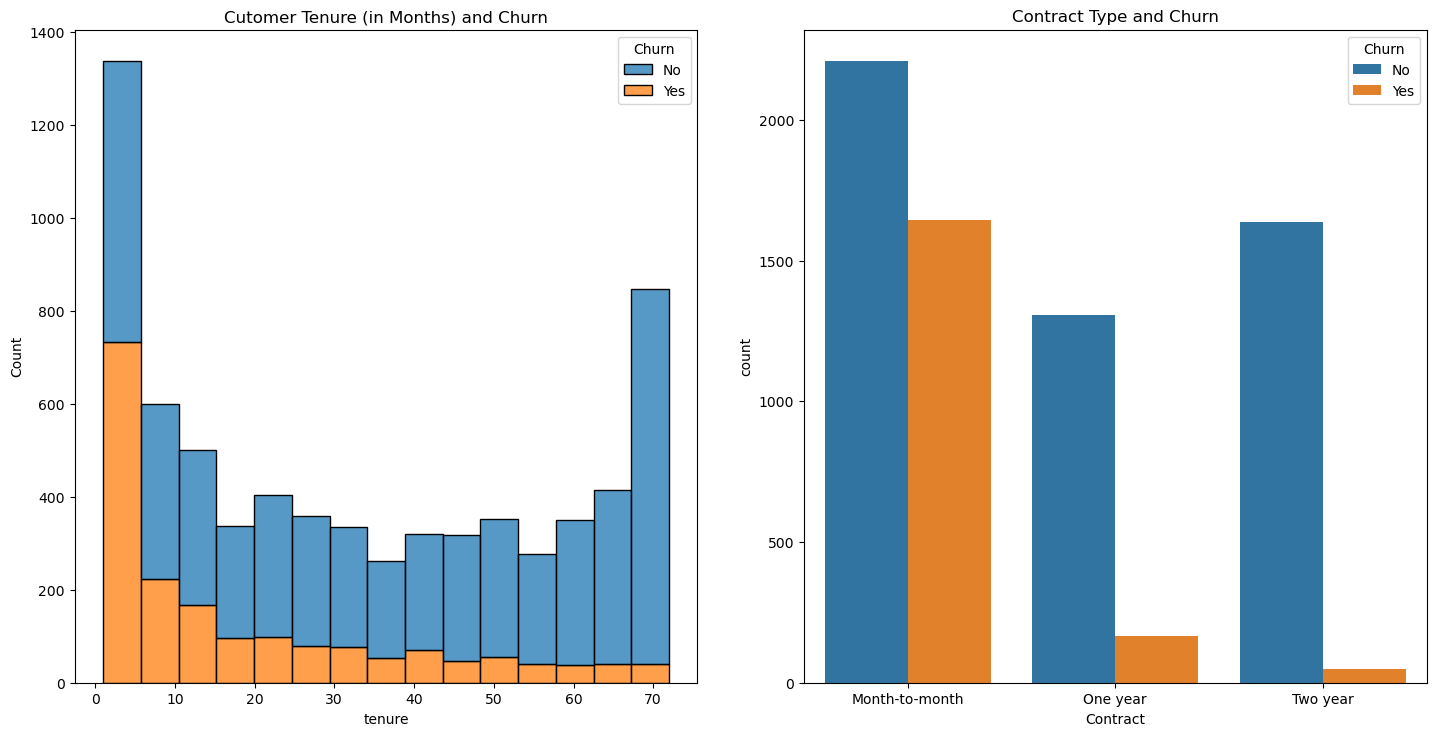

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))

sns.histplot(x        = 'tenure',
             data     = churn_df, 
             ax       = ax[0],
             hue      = 'Churn',
             multiple = 'stack').set_title('Cutomer Tenure (in Months) and Churn')

sns.countplot(x       = 'Contract', 
              data    = churn_df,
              ax      = ax[1], 
              hue     = 'Churn').set_title('Contract Type and Churn')
plt.tight_layout(pad=3.0)
plt.savefig("images/Relationship between Contract_Tenure and Churn.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

Customer tenure and churn exhibit an inverse relationship. Customers with shorter tenure particularly those under five months experience higher churn, while churn declines as tenure increases. Similarly, customers on month-to-month contracts have higher churn compared to those on one or two year contracts, indicating that longer contractual commitments are associated with stronger retention.

In summary, both longer tenure and extended contract periods contribute to lower churn, highlighting the importance of converting new or short-term customers into longer-term, committed users.

### Billing/Charges and Churn

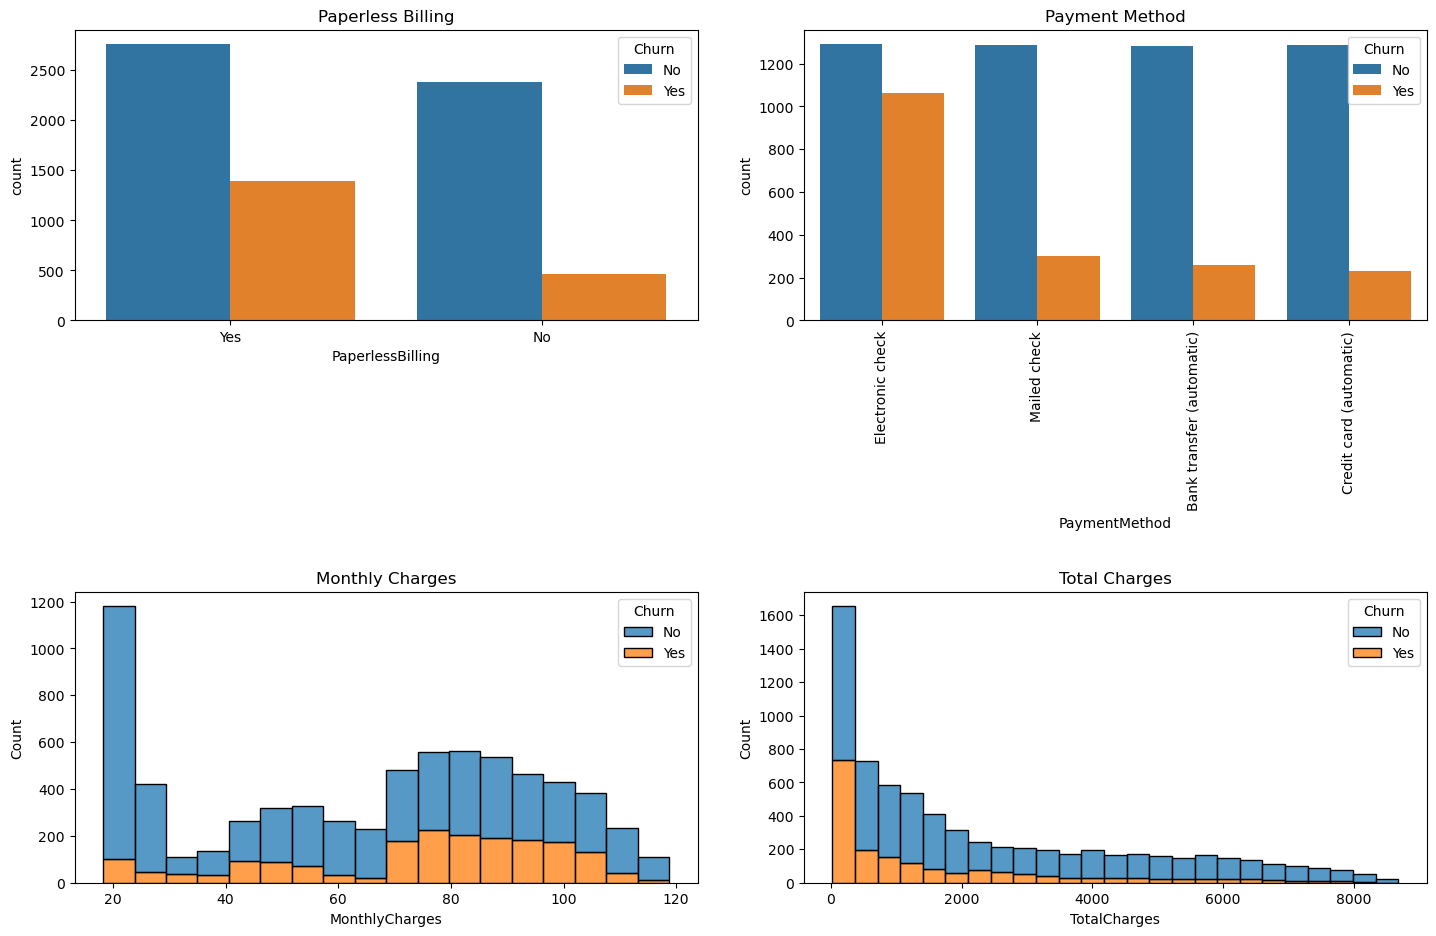

In [45]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
fig.tight_layout(pad=5.0)

#spacing between subplots
fig.subplots_adjust(hspace=0.9)

#papaerless billing
sns.countplot(x   = churn_df['PaperlessBilling'],
              ax  = ax[0,0], 
              hue = churn_df['Churn']).set_title('Paperless Billing')

#Payment Method
sns.countplot(x   = churn_df['PaymentMethod'],
              ax  = ax[0,1],
              hue = churn_df['Churn']).set_title('Payment Method')
ax[0,1].xaxis.set_tick_params(rotation = 90)

#Monthly Charges
sns.histplot(x = 'MonthlyCharges', 
             data = churn_df,
             ax = ax[1,0], 
             hue = 'Churn',
             multiple= 'stack').set_title('Monthly Charges')

#Total Charges
sns.histplot(x = 'TotalCharges',
             data = churn_df, 
             ax = ax[1,1],
             hue = 'Churn',
             multiple= 'stack').set_title('Total Charges')

plt.tight_layout(pad=3.0)
plt.savefig("images/Relationship between Billing and Charges with Churn.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

The paperless billing and payment method have not significant relation with the customer churn. However, the montly and total charges do have a interesting relation with the customer churn. The customers with higher monthly charges have higher churn count, which is quite obvious. But, the customers with higher total charges have lower churn count, which is quite interesting. This could be possible, if the customer has a long tenure or uses alot of services. Therefore, the company should focus on lowering the monthly charges for the customers in order to reduce the churn count.

## Data Preprocessing Part 2

### Outlier Removal

In [49]:
#Columns for outlier removal
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

#Using IQR method to remove outliers
Q1 = churn_df[cols].quantile(0.25)
Q3 = churn_df[cols].quantile(0.75)
IQR = Q3 - Q1

#Removing the outliers
churn_df = churn_df[~((churn_df[cols] < (Q1 - 1.5 * IQR)) |(churn_df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

## Handling Categorical Variables

In [51]:

service_columns = [ 'OnlineSecurity', 'PaperlessBilling', 'Churn','MultipleLines', 'OnlineBackup','Dependents','PhoneService',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies','Partner']

replace_dict    = {'No internet service': 'No',
                   'No phone service': 'No'
                  }

# Replacement dictionary
replace_dict = {'No internet service': 'No', 'No phone service': 'No'}

# Map service columns to 0/1
for col in service_columns:
    churn_df[col] = churn_df[col].replace(replace_dict)
    churn_df[col] = churn_df[col].map({'No': 0, 'Yes': 1})

# Map Gender to 0/1
churn_df['gender'] = churn_df['gender'].map({'Female': 0, 'Male': 1})

In [52]:
cols = ['PaymentMethod', 'Contract', 'InternetService']

# Perform one-hot encoding and drop the first category to avoid multicollinearity
one_hot_encoded_df = pd.get_dummies(churn_df[cols], columns= cols, drop_first=True)

one_hot_encoded_df = one_hot_encoded_df.astype(int)

churn_df = churn_df.join(one_hot_encoded_df)
churn_df = churn_df.drop(columns = cols)
churn_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,1,0,0,0,0,0
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,0,0,1,1,0,0,0
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,1,0,0,0,0
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,0,0,0,1,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,0,1,0,0,0,1,0


### Feature Standardization

In [54]:
#Standardizing the data
scaler = StandardScaler()
churn_df[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(churn_df[['tenure', 'MonthlyCharges', 'TotalCharges']])

## Correlation Matrix Heatmap

In [56]:
churn_corr = churn_df.corr(method = "pearson")

churn_corr[["Churn"]].round(decimals = 2).sort_values('Churn', ascending=False)



,Churn
Churn,1.00
InternetService_Fiber optic,0.31
PaymentMethod_Electronic check,0.30
MonthlyCharges,0.19
PaperlessBilling,0.19
SeniorCitizen,0.15
StreamingTV,0.07
StreamingMovies,0.06
MultipleLines,0.04
PhoneService,0.01


## Train Test Split

In [58]:
y_data = churn_df['Churn']
x_data = churn_df.drop(columns = 'Churn', axis = 1)

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size = 0.2, random_state = 42)

## Candidate Modelling

To predict customer churn, three supervised machine learning classification models will be implemented and evaluated:

1. Decision Tree Classifier
2. Random Forest Classifier
3. K Nearest Neighbors Classifier

### 1. Decision Tree Classifier

#### Hyperparameter Tuning using GridSearchCV

In [63]:
#parameter grid
param_grid = {
    'max_depth': [None,2,4,5,6,8,9,10],
    'min_samples_leaf': [2,4,6,8,10],
    'min_samples_split': [2,4,6,8,10],
    'criterion': ['gini', 'entropy'],
    'random_state': [0,42]
}

#Grid Search Object with Decision Tree Classifier
grid_search = GridSearchCV(estimator = DecisionTreeClassifier(), param_grid = param_grid, cv = 3, n_jobs = -1, verbose = 2, scoring='recall')

#Fitting the data
grid_search.fit(x_train, y_train)

#Best parameters
print(grid_search.best_params_)

Fitting 3 folds for each of 800 candidates, totalling 2400 fits
{'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 6, 'min_samples_split': 2, 'random_state': 0}


In [64]:
#instantiating a decision tree classifier
tree_model = DecisionTreeClassifier(max_depth = 6, min_samples_leaf = 6, criterion = 'entropy', min_samples_split = 2, random_state = 0)

#fit the model
tree_model.fit(x_train, y_train)

#predict on both train and test data
y_train_pred = tree_model.predict(x_train)
y_dtc_pred = tree_model.predict(x_test)

#calculate recall for both train and test
recall_train = recall_score(y_train, y_train_pred)
recall_test = recall_score(y_test, y_dtc_pred)

#print the results
print('Decison tree Recall - training set', round(recall_train, 2))
print('Decision tree Recall - testing set', round(recall_test, 2))


Decison tree Recall - training set 0.65
Decision tree Recall - testing set 0.64


### 2. Random Forest Classifier

#### Hyperparameter Tuning using GridSearchCV

In [67]:
#parameter grid
param_grid = {
    'max_depth': [2,4,6,8,10],
    'min_samples_leaf': [2,4,6,8,10],
    'min_samples_split': [2,4,6,8,10],
    'criterion': ['gini', 'entropy'],
    'random_state': [0,42]
}

#Grid Search Object with Random Forest Classifier
grid_search = GridSearchCV(estimator = RandomForestClassifier(), param_grid = param_grid, cv = 3, n_jobs = -1, verbose = 2, scoring='recall')

#Fitting the data
grid_search.fit(x_train, y_train)

#Best parameters
print(grid_search.best_params_)

Fitting 3 folds for each of 500 candidates, totalling 1500 fits
{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 6, 'random_state': 42}


In [68]:
#instantiating a decision tree classifier
rfc_model = RandomForestClassifier(max_depth = 10, min_samples_leaf = 2, criterion = 'entropy', min_samples_split = 6,n_estimators=300, random_state = 0)

#fit the model
rfc_model.fit(x_train, y_train)

#predict on both train and test data
y_train_pred = rfc_model.predict(x_train)
y_rfc_pred  = rfc_model.predict(x_test)

#calculate recall for both train and test
recall_train = recall_score(y_train, y_train_pred)
recall_test  = recall_score(y_test, y_rfc_pred)

#print the results
print('Decison tree Recall - training set', round(recall_train, 2))
print('Decision tree Recall - testing set', round(recall_test, 2))


Decison tree Recall - training set 0.63
Decision tree Recall - testing set 0.53


### 3. K Nearest Neighbors Classifier

#### Hyperparameter Tuning using GridSearchCV

In [71]:
#parameter grid
param_grid = {
    'n_neighbors': [2,4,6,8,10],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

#Grid Search Object with KNN Classifier
grid_search = GridSearchCV(estimator = KNeighborsClassifier(), param_grid = param_grid, cv = 3, n_jobs = -1, verbose = 2, scoring='recall')

#Fitting the data
grid_search.fit(x_train, y_train)

#Best parameters
print(grid_search.best_params_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
{'algorithm': 'auto', 'n_neighbors': 10, 'weights': 'distance'}


In [72]:
#KNN Classifier Object with best parameters
knn_model = KNeighborsClassifier(algorithm='auto', n_neighbors=10, weights='distance')
#fit the model
knn_model.fit(x_train, y_train)

#predict on both train and test data
y_train_pred = knn_model.predict(x_train)
y_knn_pred   = knn_model.predict(x_test)

#calculate recall for both train and test
recall_train = recall_score(y_train, y_train_pred)
recall_test  = recall_score(y_test, y_knn_pred)

#print the results
print('KNN Recall - training set', round(recall_train, 2))
print('KNN Recall - testing set', round(recall_test, 2))

KNN Recall - training set 0.99
KNN Recall - testing set 0.54


## Model Evaluation

### Confusion Matrix Heatmap

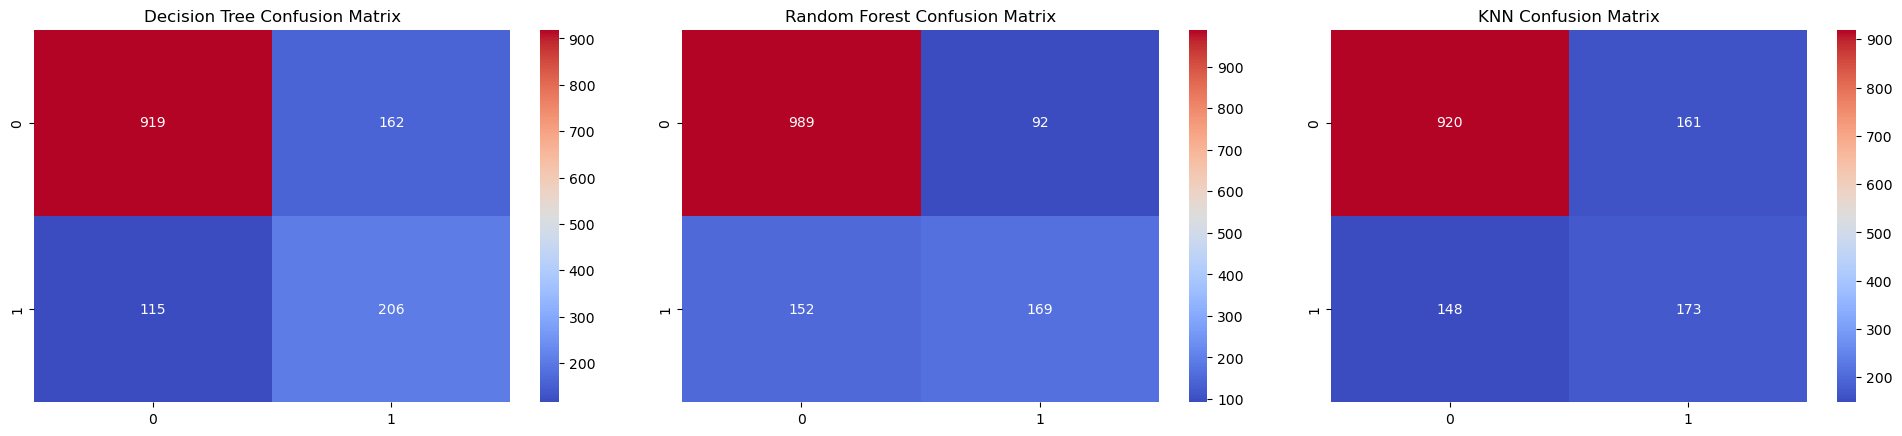

In [75]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Decision Tree Confusion Matrix - added fmt='g'
sns.heatmap(confusion_matrix(y_test, y_dtc_pred), annot=True, fmt='g', ax=ax[0], cmap='coolwarm').set_title('Decision Tree Confusion Matrix')

# Random Forest Confusion Matrix - added fmt='g'
sns.heatmap(confusion_matrix(y_test, y_rfc_pred), annot=True, fmt='g', ax=ax[1], cmap='coolwarm').set_title('Random Forest Confusion Matrix')

# KNN Confusion Matrix - added fmt='g'
sns.heatmap(confusion_matrix(y_test, y_knn_pred), annot=True, fmt='g', ax=ax[2], cmap='coolwarm').set_title('KNN Confusion Matrix')
plt.tight_layout(pad=3.0)
plt.savefig("images/Confusion Matrix Heatmap.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In a telecom customer churn environment, the primary objective is to correctly identify customers who are at risk of leaving the service provider. The Decision Tree model identifies 206 True Positives, meaning it successfully flags a large number of customers who are likely to churn. While the Random Forest model produces a higher number of True Negatives (989), the Decision Tree performs better at minimizing False Negatives (115), which represent customers who churn without being detected by the model.

From a telecom business perspective, minimizing False Negatives is particularly important. When a potential churner is not identified, the company loses the opportunity to intervene with retention strategies such as targeted promotions, service improvements, or contract incentives. Although False Positives may lead to offering retention incentives to customers who may not have churned, this cost is generally lower than the revenue loss associated with losing a customer. Therefore, the Decision Tree model is more effective for supporting proactive customer retention strategies in the telecom industry.

## Feature Importance

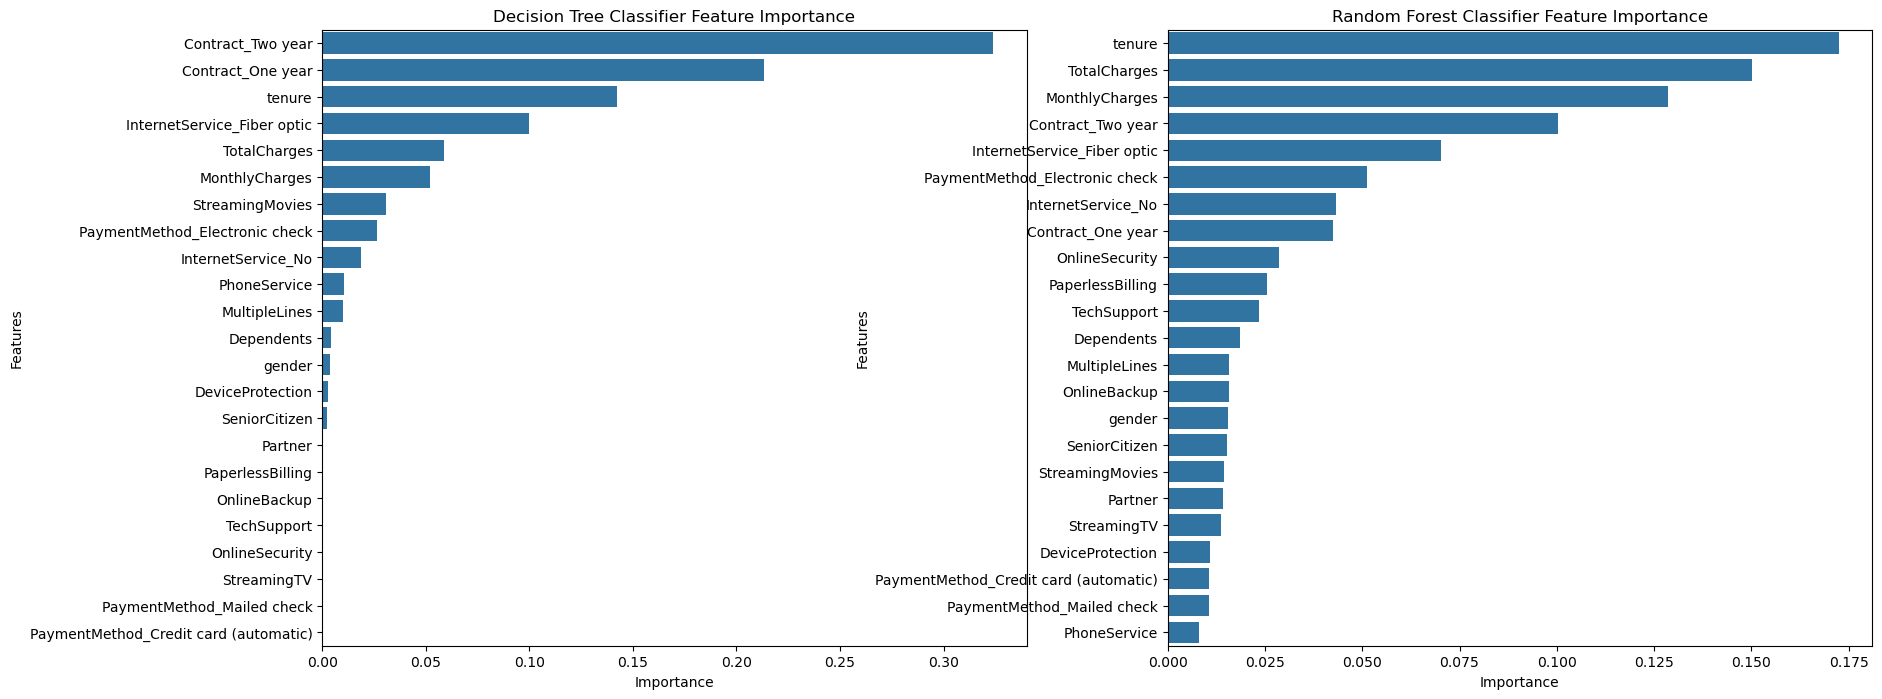

In [78]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
# Decision Tree Classifier Feature Importance
feature_df = pd.DataFrame({'Features': x_train.columns, 'Importance': tree_model.feature_importances_})
feature_df.sort_values('Importance', ascending=False, inplace=True)
sns.barplot(x = 'Importance', y = 'Features', data = feature_df, ax=ax[0]).set_title('Decision Tree Classifier Feature Importance')

# Random Forest Classifier Feature Importance
feature_df = pd.DataFrame({'Features': x_train.columns, 'Importance': rfc_model.feature_importances_})
feature_df.sort_values('Importance', ascending=False, inplace=True)
sns.barplot(x = 'Importance', y = 'Features', data = feature_df, ax=ax[1]).set_title('Random Forest Classifier Feature Importance')
plt.show()

Based on the feature importance analysis, contract type, tenure, and pricing variables (monthly and total charges) emerge as the most significant predictors of customer churn across both models. The Decision Tree model indicates that customers with long-term contracts, particularly one-year and two-year agreements, are significantly less likely to churn, suggesting that month-to-month subscribers represent the highest-risk segment.

The Random Forest model similarly highlights tenure as the most influential feature, followed by total charges and monthly charges, emphasizing the role of both customer lifecycle stage and pricing exposure in churn behavior.

From a telecom business perspective, these findings suggest a twofold retention strategy. First, telecom providers should encourage customers to transition from month-to-month plans to longer-term contracts, which help create stronger customer commitment and reduce churn risk. Second, companies should closely monitor customers with shorter tenure and higher service charges, as these customers are more likely to be sensitive to pricing and service experience, making them more vulnerable to switching providers.

## Conclusion

This analysis aimed to develop a predictive model to identify customers likely to churn so that the company can take proactive retention actions. Exploratory data analysis and feature engineering were first conducted to better understand the dataset and prepare the variables for modeling. Several classification models were then trained and evaluated using recall as the primary metric. Recall was prioritized because the dataset is class-imbalanced, with significantly fewer churners than non-churners. In this context, correctly identifying customers who are likely to churn is more important than simply maximizing overall accuracy.

Among the models evaluated, the Decision Tree demonstrated the strongest performance in identifying churners. The optimized Decision Tree achieved a recall of 0.64 on the test set, outperforming the Random Forest (0.53) and KNN (0.54) models. While the KNN model showed extremely high recall on the training set (0.99), its much lower test recall indicates overfitting, meaning it does not generalize well to unseen data. The Decision Tree, in contrast, maintained relatively consistent recall between training (0.65) and testing (0.64), suggesting better generalization and more reliable performance.

Key insights from the modeling process show that focusing on recall allows the model to capture a larger proportion of customers who are actually at risk of leaving. By correctly identifying more potential churners, the company can target retention strategies such as personalized offers, improved service support, or loyalty incentives.

Overall, the Decision Tree model is recommended as the final model because it provides the highest recall on unseen data while maintaining balanced performance, making it the most effective approach for identifying customers at risk of churn and supporting proactive customer retention efforts.